In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import seaborn as sns
import datasets
from datasets import load_dataset, Dataset

In [2]:
dataset_id = "NingLab/ECInstruct"

In [3]:
dataset = load_dataset(dataset_id)
dataset

README.md:   0%|          | 0.00/3.29k [00:00<?, ?B/s]

dataset.json:   0%|          | 0.00/529M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/263562 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['output', 'input', 'options', 'task', 'setting', 'split', 'few_shot_example', 'instruction'],
        num_rows: 263562
    })
})

In [4]:
dataset["train"][0]

{'output': 'A: The product is relevant to the query, and satisfies all the query specifications.',
 'input': '{"query": "fathers christmas gift", "product title": "RAK Magnetic Wristband - Men & Women\'s Tool Bracelet with 10 Strong Magnets to Hold Screws, Nails and Drilling Bits - Gift Ideas for Dad, Husband, Handyman or Handy Woman"}',
 'options': '["A: The product is relevant to the query, and satisfies all the query specifications.", "B: The product is somewhat relevant. It fails to fulfill some aspects of the query but the product can be used as a functional substitute.", "C: The product does not fulfill the query, but could be used in combination with a product exactly matching the query.", "D: The product is irrelevant to the query."]',
 'task': 'Multiclass_Product_Classification',
 'setting': 'IND_Single_Instruction',
 'split': 'train',
 'few_shot_example': None,
 'instruction': 'What is the relevance between the query and the product title below? Answer from one of the options

In [5]:
df = pd.DataFrame(dataset['train'])

In [6]:
print(df["setting"].unique())

['IND_Single_Instruction' 'IND_Diverse_Instruction'
 'OOD_Unseen_Instruction' 'IND_Diverse_Instruction_1-shot'
 'OOD_Single_Instruction' 'OOD_Diverse_Instruction_1-shot'
 'IND_Unseen_Instruction' 'OOD_Diverse_Instruction']


In [15]:
print(df.value_counts)

<bound method DataFrame.value_counts of                                                    output  \
0       A: The product is relevant to the query, and s...   
1                                                      no   
2                                                       B   
3                                                       H   
4       B: The product is somewhat relevant. It fails ...   
...                                                   ...   
263557                                        D: negative   
263558                                   A: very positive   
263559                                   A: very positive   
263560                                   E: very negative   
263561                                        B: positive   

                                                    input  \
0       {"query": "fathers christmas gift", "product t...   
1       {"question": "can i place a few ashes of my la...   
2       {"Product 1:": "Duralex Amalfi Glass

/tmp/ipykernel_30/3683545599.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  count = options_counts[val]


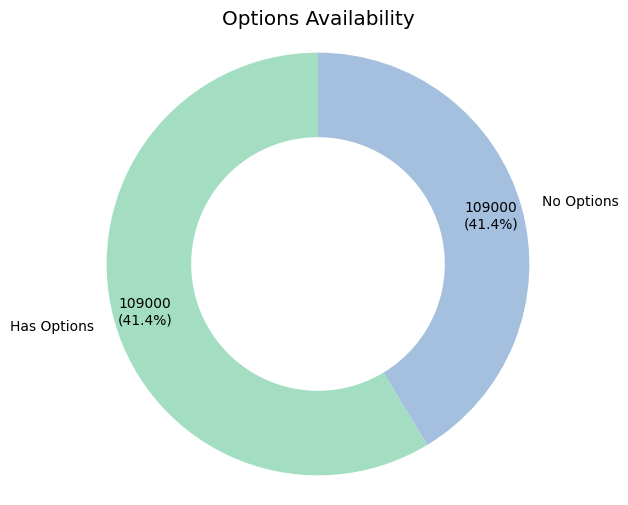

In [7]:
options_counts = df['options'].isnull().value_counts()
options_counts.index = ['Has Options', 'No Options']  # Rename the index

# Create a custom function to display count and percentage
def count_percent(val):
    total = sum(options_counts)
    count = options_counts[val]
    percent = 100 * count / total
    return f'{count}\n({percent:.1f}%)'

# Create a smaller and thicker donut chart
plt.figure(figsize=(6, 6))
# Define better pastel colors
pastel_colors = ['#A4DEC2', '#A4C0DE']  # Softer pastel colors
plt.pie(options_counts, 
        labels=options_counts.index, 
        autopct=lambda p: count_percent(0 if p == 0 else 1 if p > 0 else 0),  # Adjusted for correct indexing
        startangle=90, 
        pctdistance=0.85, 
        colors=pastel_colors,
        wedgeprops=dict(width=0.4))  # Adjust width for thickness

centre_circle = plt.Circle((0, 0), 0.55, fc='white')  # Create a smaller white circle at the center
fig = plt.gcf()
fig.gca().add_artist(centre_circle)  # Add the circle in the pie chart
plt.title('Options Availability')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Show plot
plt.show()

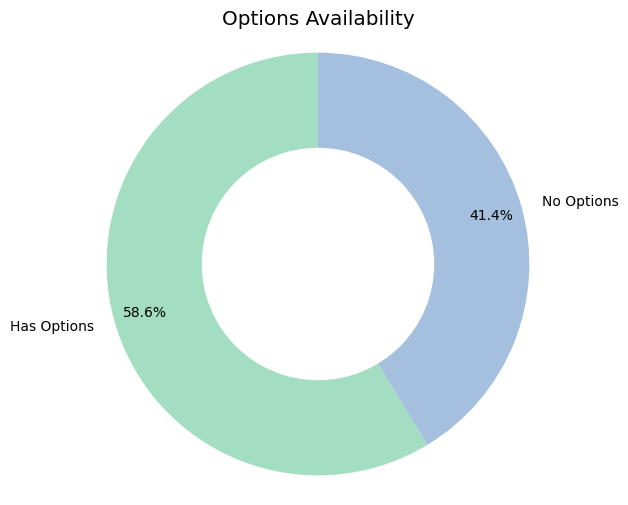

In [8]:
# Count occurrences of None and actual options
options_counts = df['options'].isnull().value_counts()

# Create a donut chart
plt.figure(figsize=(6, 6))
plt.pie(options_counts, labels=['Has Options', 'No Options'], autopct='%1.1f%%', startangle=90, pctdistance=0.85, colors=pastel_colors)
centre_circle = plt.Circle((0, 0), 0.55, fc='white')  # Create a white circle at the center
fig = plt.gcf()
fig.gca().add_artist(centre_circle)  # Add the circle in the pie chart
plt.title('Options Availability')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Show plot
plt.show()

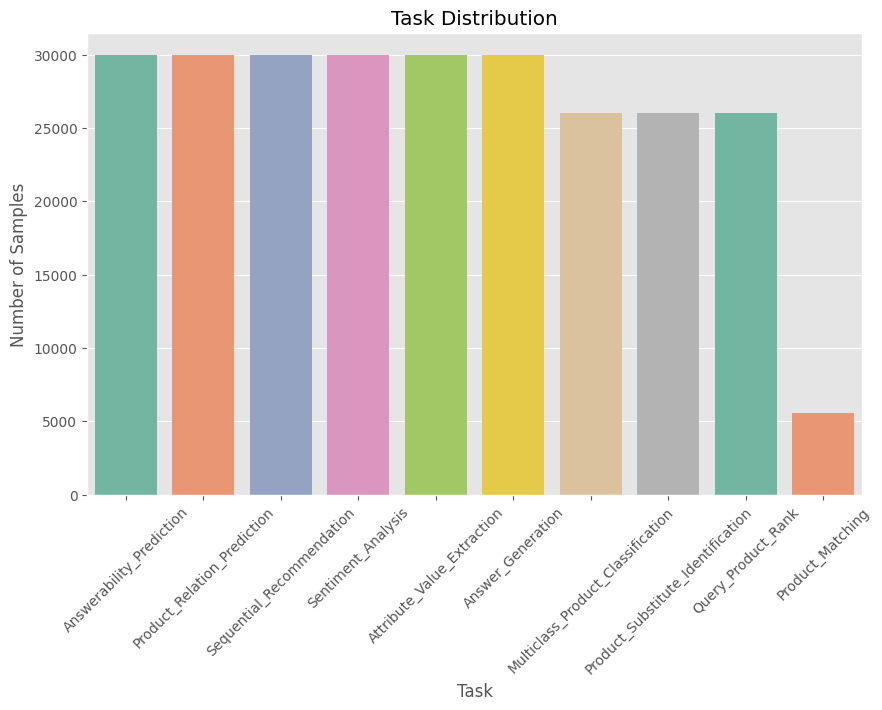

In [9]:
# --------------------------------------
# 1. Task Variability Analysis
# --------------------------------------

# Count the occurrences of each unique task
task_counts = df['task'].value_counts()

# Plot the task distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=task_counts.index, y=task_counts.values, palette='Set2')
plt.xticks(rotation=45)
plt.title('Task Distribution')
plt.ylabel('Number of Samples')
plt.xlabel('Task')
plt.show()

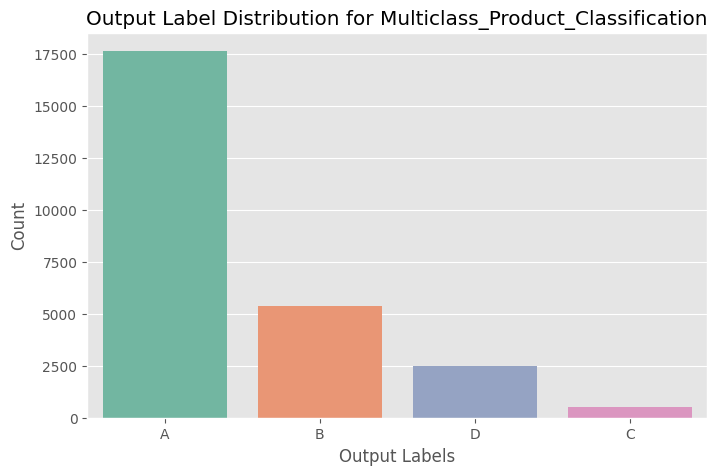

A: The product is relevant to the query, and satisfies all the query specifications.
B: The product is somewhat relevant. It fails to fulfill some aspects of the query but the product can be used as a functional substitute.
D: The product is irrelevant to the query.
C: The product does not fulfill the query, but could be used in combination with a product exactly matching the query.


In [10]:
task_specific_df = df[df['task'] == 'Multiclass_Product_Classification']

# --------------------------------------
# 1. Output Distribution Analysis
# --------------------------------------

# Get the distribution of the output labels
output_counts = task_specific_df['output'].value_counts()

short_labels = ['A', 'B', 'D', 'C']  
original_labels = output_counts.index.tolist()
label_mapping = {original: short for original, short in zip(original_labels, short_labels)}
shortened_counts = output_counts.rename(index=label_mapping)

# Plot the output label distribution with shortened labels
plt.figure(figsize=(8, 5))
sns.barplot(x=shortened_counts.index, y=shortened_counts.values, palette='Set2')
plt.title('Output Label Distribution for Multiclass_Product_Classification')
plt.ylabel('Count')
plt.xlabel('Output Labels')
plt.show()

# Display the mapping of short labels to original labels
for short, original in label_mapping.items():
    print(f'{short}')


In [11]:

instruction_counts = df['instruction'].value_counts()

# Display the count of unique instructions
print("Count of Unique Instructions:")
print(len(instruction_counts))

Count of Unique Instructions:
60


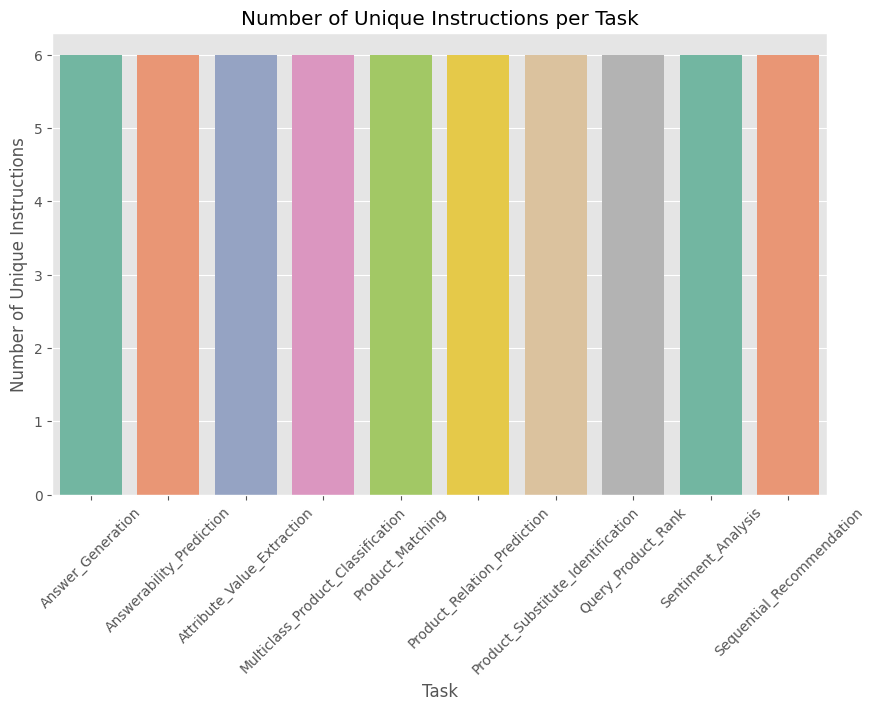

In [12]:
unique_instructions_per_task = df.groupby('task')['instruction'].nunique()

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=unique_instructions_per_task.index, y=unique_instructions_per_task.values, palette='Set2')
plt.xticks(rotation=45)
plt.title('Number of Unique Instructions per Task')
plt.ylabel('Number of Unique Instructions')
plt.xlabel('Task')
plt.show()